# 32 - Why do the m = 10¹¹ GeV limits differ? Quadrature vs DE sink

The strategy-5 + sink scan (`connect/new/11`, emulator `strat5_sink`) gives a different f_acc limit from the
strategy-4 scan (`connect/Lite/11`, emulator `q501`: 501 bins, no sink). Candidates: the DE sink, the daughter
quadrature (strategy 4 → 5), their interaction, the emulators and the f_acc prior.

This notebook tests the CLASS-level candidates. All settings and ΛCDM parameters are those of
`connect/Lite_lin/11` (log.param + best fit); only f_acc, the daughter quadrature and `acc_de_sink` change.

- **2×2 design** at each f_acc: {s4 501 bins, s5 50/decade} × {sink off, on}. The corners s4/off and s5/on are
  the training setups of the two emulators.
- **Strategy-5 settings** (sink off) at a few f_acc, plus s4 with 1001 bins.
- **Signal** = a setup at f_acc vs the same setup at f_acc = 1e-6. The upper limit scales as the f_acc where the
  signal Δχ² reaches a fixed value, so the ratio of those f_acc between setups predicts the limit shift.
- **Chain limits** from the local chains: same log10 prior (`connect/Lite/11` vs `connect/new/11`) and same
  linear prior (`connect/Lite_lin/11` vs `new/11`, full CLASS s5 without sink).

Not tested: emulator accuracy. Runtime about 1 h, mostly the strategy-4 runs. Results are cached in
`32_cache.pkl`; delete it after rebuilding CLASS.

In [1]:
import json
import pickle
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from classy import Class

import figkit as fk

fk.use("quick")


def find_root(start=None):
    start = Path.cwd() if start is None else start
    for d in [start, *start.parents]:
        if (d/'chains'/'fixed_masses').is_dir():
            return d
    raise FileNotFoundError('no chains/fixed_masses above {}'.format(start))


CHAINS = find_root()/'chains'/'fixed_masses'


def read_bestfit(path):
    with open(path) as fh:
        names = [s.strip() for s in fh.readline().lstrip('#').split(',')]
        values = [float(v) for v in fh.readline().split()]
    return dict(zip(names, values))


BF = read_bestfit(CHAINS/'connect'/'Lite_lin'/'11'/'11_lin.bestfit')
LCDM = {k: BF[k] for k in ('omega_b', 'omega_cdm', 'H0', 'ln10^{10}A_s', 'n_s', 'tau_reio')}

# connect/Lite_lin/11/log.param without the daughter quadrature, which is set per setup
SETTINGS = {'N_ncdm': 2, 'N_ur': 2.0308,
            'm_ncdm': '0.06, 0.1', 'deg_ncdm': '1, 1', 'T_ncdm': '0.71611, 1.0',
            'm_acc_in_GeV': 1e11, 'kappa_acc': 12.1, 'a_t_acc': 0.133, 'vary_Gamma_acc': 'yes',
            'ncdm_fluid_approximation': 3, 'gauge': 'synchronous', 'reionization_z_start_max': 80,
            'evolver': 0, 'output': 'mPk, lCl, tCl, pCl', 'P_k_max_1/Mpc': 1.0,
            'lensing': 'yes', 'l_max_scalars': 2508}

print('LCDM best fit:', LCDM)

LCDM best fit: {'omega_b': 0.02256944, 'omega_cdm': 0.1175042, 'H0': 68.47743, 'ln10^{10}A_s': 3.056426, 'n_s': 0.972248, 'tau_reio': 0.06151263}


In [2]:
LMAX = 2500
ELL = np.arange(2, LMAX + 1)
KK = np.logspace(-4, np.log10(0.9), 300)                             # 1/Mpc, inside P_k_max
Z_BAO = np.array([0.295, 0.510, 0.706, 0.934, 1.321, 1.484, 2.330])  # DESI DR2 effective z
CACHE = Path('32_cache.pkl')
cache = pickle.loads(CACHE.read_bytes()) if CACHE.exists() else {}


def params(f_acc, strategy, n_q=None, sink=False, extra=None):
    """Chain settings + LCDM best fit; n_q = None lets strategy 5 use accdm_q_bins_per_decade."""
    p = {**LCDM, **SETTINGS, 'f_acc': f_acc,
         'ncdm_quadrature_strategy': '0, {:d}'.format(strategy),
         'acc_de_sink': 'yes' if sink else 'no'}
    if n_q is not None:
        p['ncdm_N_momentum_bins'] = '15, {:d}'.format(n_q)
    p.update(extra or {})
    return p


def run(p):
    cosmo = Class()
    cosmo.set(p)
    t0 = time.time()
    try:
        cosmo.compute()
        cl = cosmo.lensed_cl(LMAX)
        out = {s: np.array(cl[s][2:]) for s in ('tt', 'ee', 'te', 'pp')}
        out['pk_cb'] = np.array([cosmo.pk_cb(k, 0.0) for k in KK])
        out['pk_m'] = np.array([cosmo.pk(k, 0.0) for k in KK])
        rd = cosmo.rs_drag()
        out['DM_rd'] = np.array([cosmo.angular_distance(z)*(1 + z) for z in Z_BAO])/rd
        out['DH_rd'] = np.array([1/cosmo.Hubble(z) for z in Z_BAO])/rd
        out.update(cosmo.get_current_derived_parameters(['100*theta_s', 'Omega_Lambda', 'sigma8']))
        out['sigma8_cb'] = cosmo.sigma8_cb()
        out['T_cmb'] = cosmo.T_cmb()
    finally:
        cosmo.struct_cleanup()
        cosmo.empty()
    out['sec'] = time.time() - t0
    return out


def cached_run(p):
    key = json.dumps(p, sort_keys=True)
    if key not in cache:
        cache[key] = run(p)
        CACHE.write_bytes(pickle.dumps(cache))
    return cache[key]

## Runs

Corners on the full f_acc grid (includes the Lite_lin best fit 3.4e-4); settings variants on a coarser grid.
Strategy 5 without explicit bins uses the default 50 bins per decade, as in the `strat5_sink` training.

In [3]:
F_REF = 1e-6                     # signal reference; accDM needs f_acc > 0
F_CORNER = [F_REF, 3.39e-4, 1e-3, 3e-3, 1e-2, 3e-2, 0.1]
F_VARIANT = [F_REF, 1e-3, 1e-2, 0.1]

# label: (strategy, n_q, sink, extra)
CORNERS = {'s4 501, sink off': (4, 501, False, {}),
           's4 501, sink on': (4, 501, True, {}),
           's5 50/dec, sink off': (5, None, False, {}),
           's5 50/dec, sink on': (5, None, True, {})}
VARIANTS = {'s4 1001': (4, 1001, False, {}),
            's5 25/dec': (5, None, False, {'accdm_q_bins_per_decade': 25}),
            's5 100/dec': (5, None, False, {'accdm_q_bins_per_decade': 100}),
            's5 51 bins': (5, 51, False, {}),
            's5 101 bins': (5, 101, False, {}),
            's5 a_min at 1e-8': (5, None, False, {'accdm_q_number_tol': 1e-8}),
            's5 tol_pert 1e-6': (5, None, False, {'tol_perturbations_integration': 1e-6}),
            's5 smooth births': (5, None, False, {'accdm_smooth_births': 1})}
SETUPS = {**CORNERS, **VARIANTS}
REF = 's4 501, sink off'
# variants are compared with the corner of the same strategy
VARIANT_BASE = {lab: REF if SETUPS[lab][0] == 4 else 's5 50/dec, sink off' for lab in VARIANTS}

jobs = [(lab, f) for lab in CORNERS for f in F_CORNER] + [(lab, f) for lab in VARIANTS for f in F_VARIANT]
res = {}
for lab, f in jobs:
    strategy, n_q, sink, extra = SETUPS[lab]
    try:
        res[(lab, f)] = cached_run(params(f, strategy, n_q, sink, extra))
    except Exception as err:
        print('{:<22s} f = {:.1e}  FAILED - {}'.format(lab, f, err))
        continue
    print('{:<22s} f = {:.1e}  {:5.0f} s'.format(lab, f, res[(lab, f)]['sec']))

s4 501, sink off       f = 1.0e-06     56 s
s4 501, sink off       f = 3.4e-04     56 s
s4 501, sink off       f = 1.0e-03     59 s
s4 501, sink off       f = 3.0e-03     60 s
s4 501, sink off       f = 1.0e-02     58 s
s4 501, sink off       f = 3.0e-02     59 s
s4 501, sink off       f = 1.0e-01     65 s
s4 501, sink on        f = 1.0e-06     72 s
s4 501, sink on        f = 3.4e-04     67 s
s4 501, sink on        f = 1.0e-03     66 s
s4 501, sink on        f = 3.0e-03     64 s
s4 501, sink on        f = 1.0e-02     66 s
s4 501, sink on        f = 3.0e-02     65 s
s4 501, sink on        f = 1.0e-01     66 s
s5 50/dec, sink off    f = 1.0e-06      8 s
s5 50/dec, sink off    f = 3.4e-04     11 s
s5 50/dec, sink off    f = 1.0e-03      9 s
s5 50/dec, sink off    f = 3.0e-03      8 s
s5 50/dec, sink off    f = 1.0e-02      9 s
s5 50/dec, sink off    f = 3.0e-02     11 s
s5 50/dec, sink off    f = 1.0e-01      8 s
s5 50/dec, sink on     f = 1.0e-06      8 s
s5 50/dec, sink on     f = 3.4e-

## Metrics

Approximate Δχ² between two runs, per probe. Only ratios between setups are meant to be trusted.

- **CMB:** lensed TT, EE, TE, ℓ = 2–2500, Gaussian covariance with Planck-like noise (7′ beam, 33 / 70 μK′), f_sky = 0.6.
- **Lensing:** shift of the (2L+1)-weighted mean of C_L^φφ over L = 8–400, against a 2.5% amplitude error.
- **BAO:** D_M/r_d and D_H/r_d at the 7 DESI DR2 redshifts, 1% error each, uncorrelated.

In [4]:
FSKY = 0.6
ARCMIN = np.pi/(180*60)
BEAM, NOISE_T, NOISE_P = 7.0*ARCMIN, 33.0*ARCMIN, 70.0*ARCMIN    # beam in rad, noise in uK rad
SIGMA_LENS = 0.025
SIGMA_BAO = 0.01
L_LENS = (ELL >= 8) & (ELL <= 400)
PARTS = ('total', 'cmb', 'lens', 'bao')


def noise_cl(sigma, t_cmb):
    """Beam-deconvolved white noise in the dimensionless units of lensed_cl."""
    return (sigma/(t_cmb*1e6))**2*np.exp(ELL*(ELL + 1)*BEAM**2/(8*np.log(2)))


def chi2_parts(a, b):
    """Approximate delta chi2 of run a against run b, per probe."""
    tt = b['tt'] + noise_cl(NOISE_T, b['T_cmb'])
    ee = b['ee'] + noise_cl(NOISE_P, b['T_cmb'])
    te = b['te']
    d = np.array([a['tt'] - b['tt'], a['ee'] - b['ee'], a['te'] - b['te']]).T
    cov = np.array([[2*tt**2, 2*te**2, 2*tt*te],
                    [2*te**2, 2*ee**2, 2*ee*te],
                    [2*tt*te, 2*ee*te, tt*ee + te**2]])/((2*ELL + 1)*FSKY)
    x = np.linalg.solve(np.moveaxis(cov, 2, 0), d[:, :, None])[:, :, 0]
    cmb = float(np.sum(d*x))
    w = (2*ELL + 1)[L_LENS]
    a_lens = np.sum(w*(a['pp']/b['pp'] - 1)[L_LENS])/np.sum(w)
    lens = float((a_lens/SIGMA_LENS)**2)
    bao = float(np.sum((a['DM_rd']/b['DM_rd'] - 1)**2 + (a['DH_rd']/b['DH_rd'] - 1)**2)/SIGMA_BAO**2)
    return {'total': cmb + lens + bao, 'cmb': cmb, 'lens': lens, 'bao': bao}


def frac(a, b):
    """Fractional differences of run a relative to run b; TE normalised by sqrt(TT EE)."""
    d = {s: a[s]/b[s] - 1 for s in ('tt', 'ee', 'pp', 'pk_cb', 'pk_m', 'DM_rd', 'DH_rd',
                                    '100*theta_s', 'Omega_Lambda', 'sigma8', 'sigma8_cb')}
    d['te'] = (a['te'] - b['te'])/np.sqrt(b['tt']*b['ee'])
    return d


print('sanity at f_acc = {:.0e}: every setup should match {} (dchi2 << 1)'.format(F_REF, REF))
for lab in SETUPS:
    if lab != REF and (lab, F_REF) in res:
        c = chi2_parts(res[(lab, F_REF)], res[(REF, F_REF)])
        print('  {:<22s} dchi2 {:.2e}'.format(lab, c['total']))

sanity at f_acc = 1e-06: every setup should match s4 501, sink off (dchi2 << 1)
  s4 501, sink on        dchi2 4.07e-02
  s5 50/dec, sink off    dchi2 4.26e-08
  s5 50/dec, sink on     dchi2 7.63e-08
  s4 1001                dchi2 1.15e-07
  s5 25/dec              dchi2 5.57e-08
  s5 100/dec             dchi2 2.44e-08
  s5 51 bins             dchi2 4.32e-08
  s5 101 bins            dchi2 1.97e-08
  s5 a_min at 1e-8       dchi2 4.07e-02
  s5 tol_pert 1e-6       dchi2 8.99e-08
  s5 smooth births       dchi2 4.28e-08


## 1. How different are the spectra?

Δχ² of each corner against the s4/501/no-sink run at the same f_acc, and fractional differences at f_acc = 0.01.

In [5]:
print('dchi2 vs {} at the same f_acc: total (CMB / lens / BAO)'.format(REF))
print('{:<22s}'.format('f_acc') + ''.join('{:>26.1e}'.format(f) for f in F_CORNER[1:]))
for lab in list(CORNERS)[1:]:
    cells = []
    for f in F_CORNER[1:]:
        if (lab, f) in res and (REF, f) in res:
            c = chi2_parts(res[(lab, f)], res[(REF, f)])
            cells.append('{:.2g} ({:.2g}/{:.2g}/{:.2g})'.format(c['total'], c['cmb'], c['lens'], c['bao']))
        else:
            cells.append('-')
    print('{:<22s}'.format(lab) + ''.join('{:>26s}'.format(s) for s in cells))

F_SHOW = 1e-2
print()
print('derived at f_acc = {:g}, fractional difference vs the base setup'.format(F_SHOW))
pairs_all = [(lab, REF) for lab in list(CORNERS)[1:]] + [(lab, VARIANT_BASE[lab]) for lab in VARIANTS]
for lab, base in pairs_all:
    if (lab, F_SHOW) in res and (base, F_SHOW) in res:
        d = frac(res[(lab, F_SHOW)], res[(base, F_SHOW)])
        print('  {:<22s} vs {:<20s} theta_s {:+.1e}  Omega_L {:+.1e}  sigma8 {:+.1e}  sigma8_cb {:+.1e}'.format(
            lab, base, d['100*theta_s'], d['Omega_Lambda'], d['sigma8'], d['sigma8_cb']))

dchi2 vs s4 501, sink off at the same f_acc: total (CMB / lens / BAO)
f_acc                                    3.4e-04                   1.0e-03                   3.0e-03                   1.0e-02                   3.0e-02                   1.0e-01
s4 501, sink on       0.001 (0.001/2.6e-06/1.1e-11)0.0088 (0.0088/2.3e-05/1.9e-11)0.083 (0.083/0.00021/2.5e-11)0.92 (0.91/0.0022/2.7e-10)     8.1 (8/0.018/2.4e-09)      74 (74/0.17/2.4e-08)
s5 50/dec, sink off   6.5e-07 (6.5e-07/2.3e-10/1.9e-09)0.041 (0.041/4.1e-07/1.1e-08)1.8e-05 (1.8e-05/1.1e-08/1.1e-07)0.0023 (0.0023/2.4e-07/1.2e-06) 0.12 (0.12/1.2e-05/1e-05)   8.4 (8.4/0.0012/0.0001)
s5 50/dec, sink on    0.001 (0.001/2.7e-06/1.7e-09)0.0086 (0.0085/2.3e-05/1.2e-08)0.081 (0.081/0.0002/1.1e-07)0.93 (0.93/0.0023/1.1e-06)   8.5 (8.5/0.021/9.9e-06)1e+02 (1e+02/0.15/9.9e-05)

derived at f_acc = 0.01, fractional difference vs the base setup
  s4 501, sink on        vs s4 501, sink off     theta_s +2.5e-04  Omega_L +0.0e+00  sigma8 -1.0e-05  sig

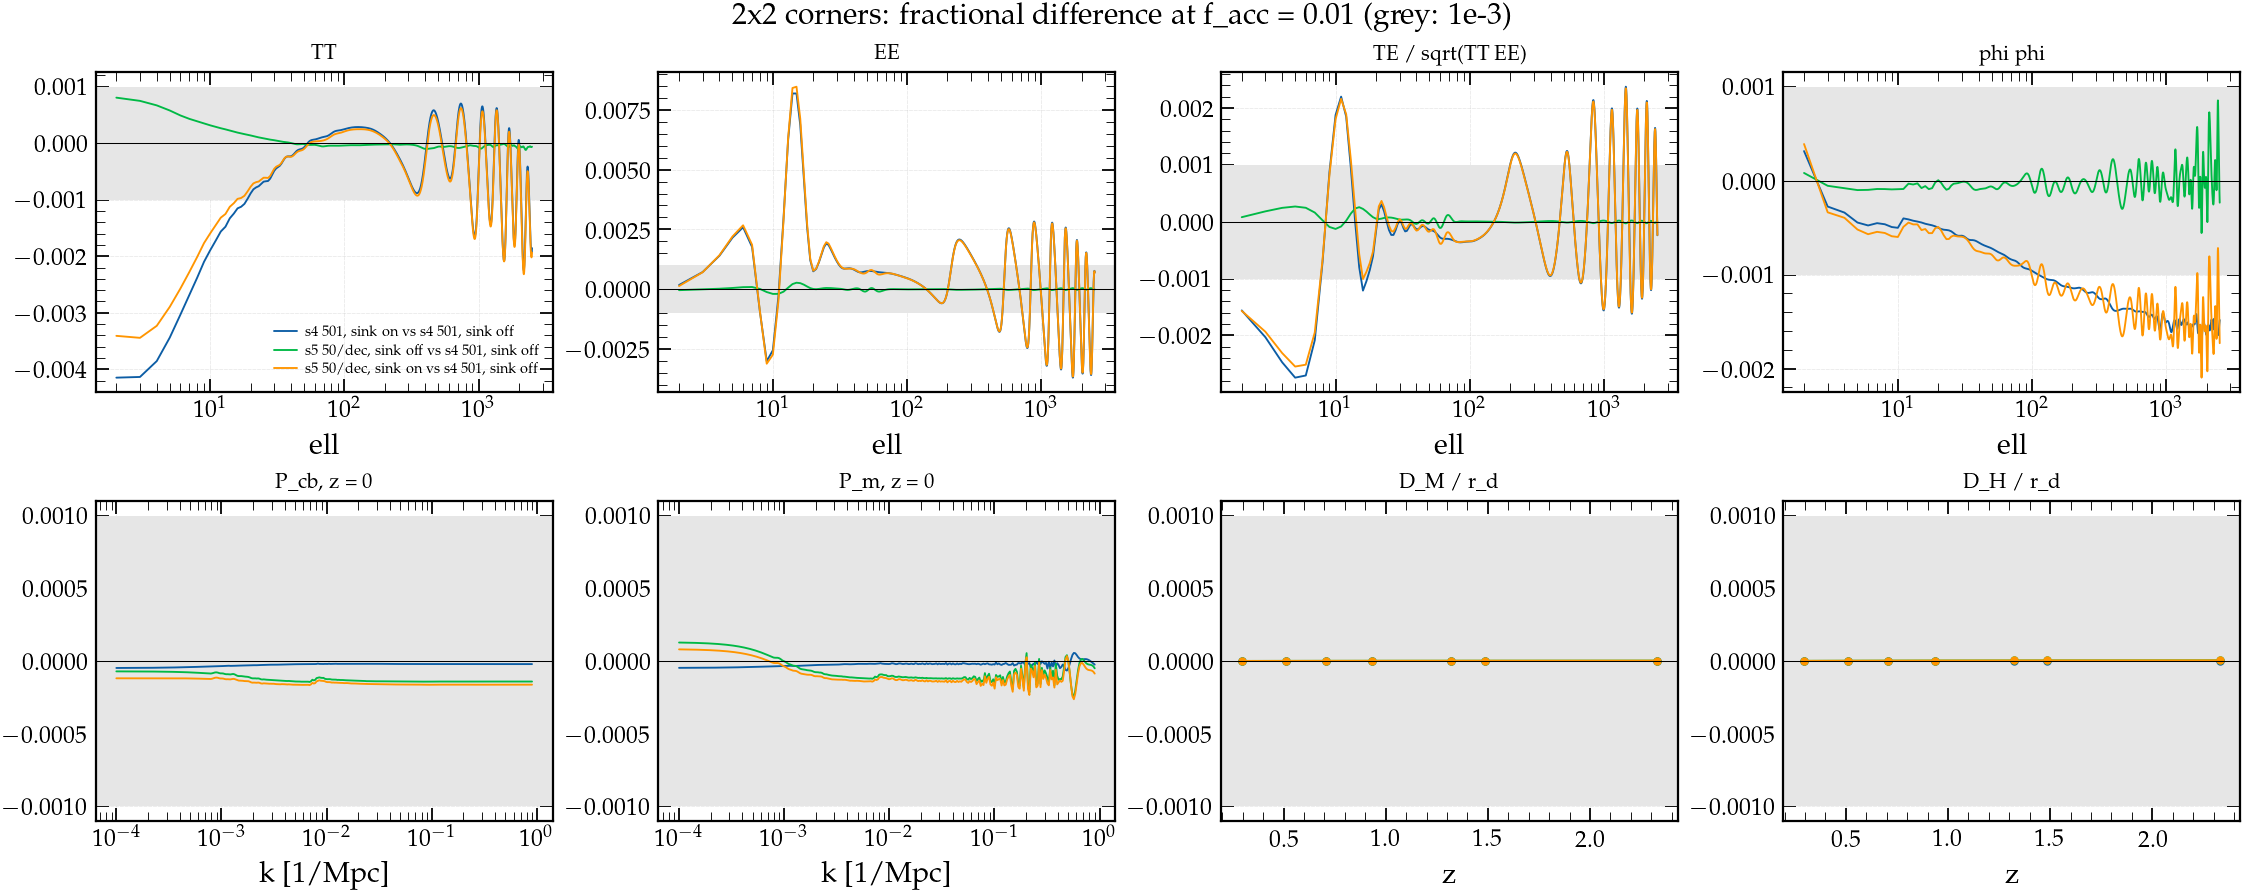

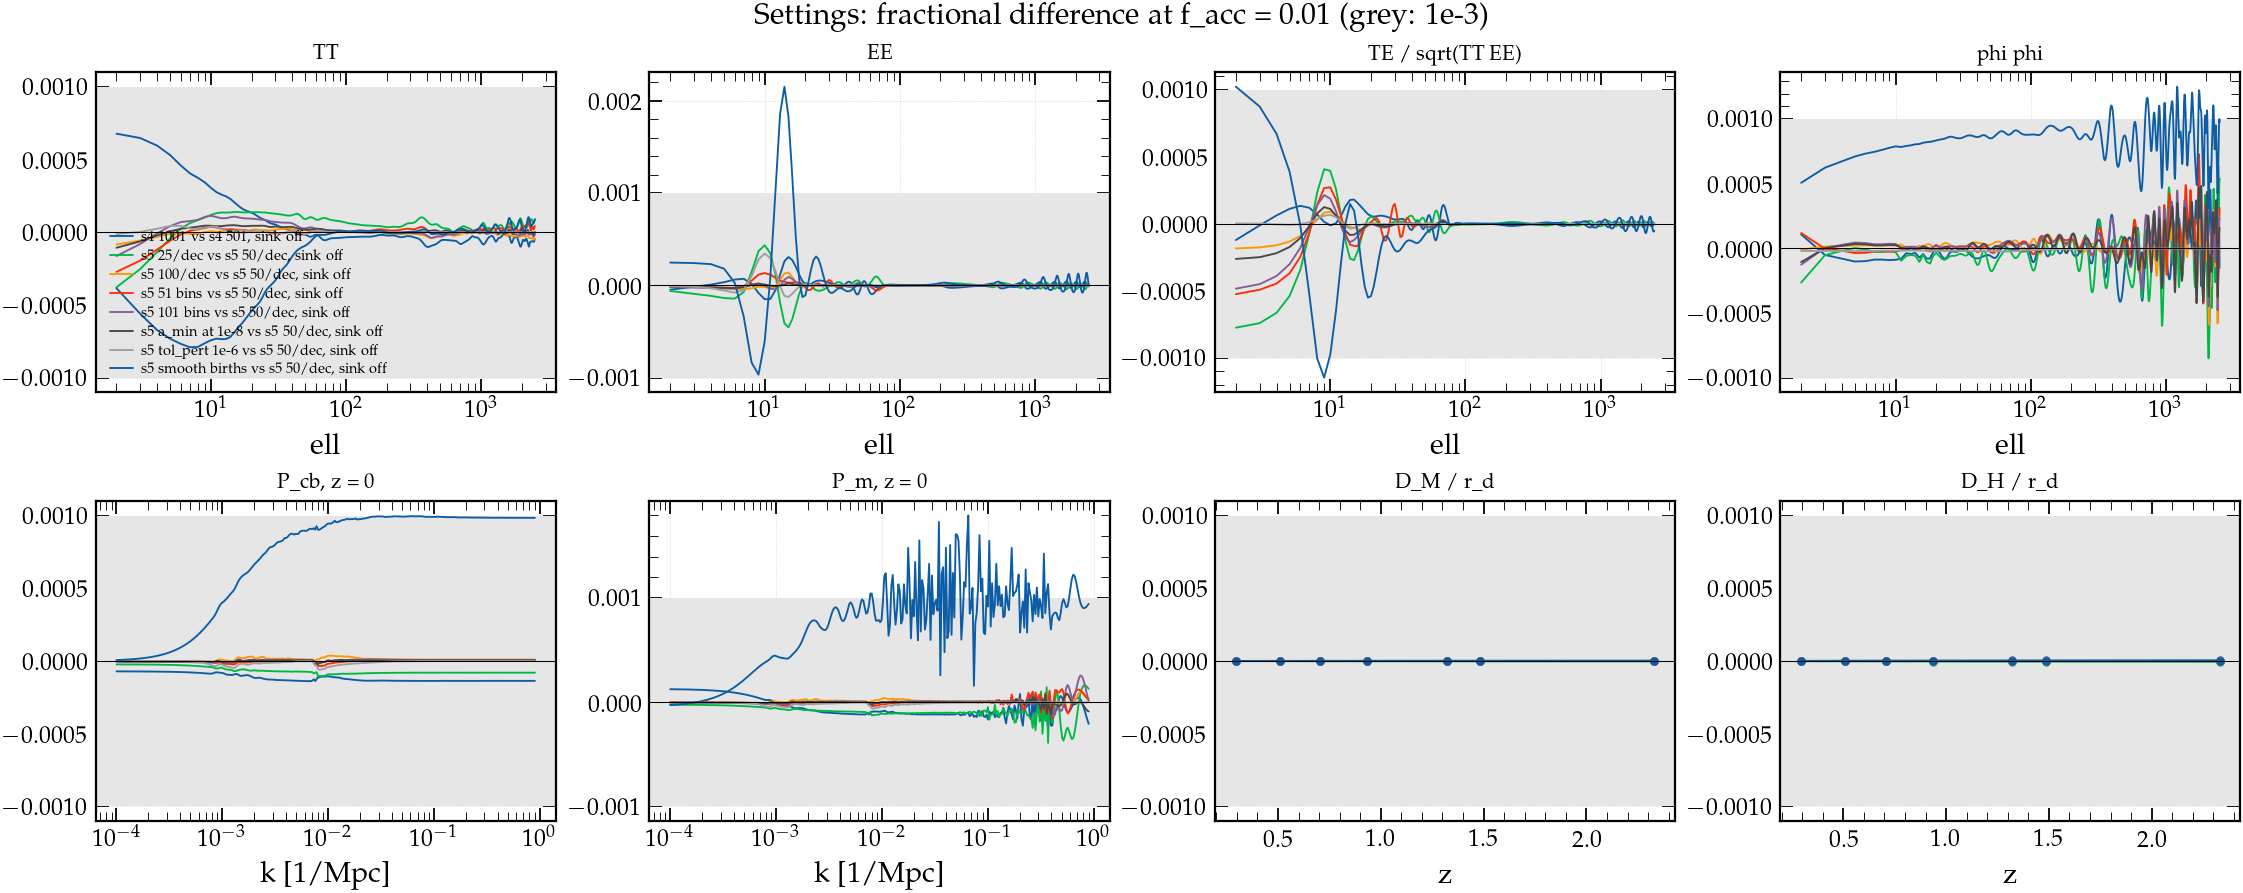

In [6]:
PANELS = [('tt', 'TT', 'ell'), ('ee', 'EE', 'ell'), ('te', 'TE / sqrt(TT EE)', 'ell'),
          ('pp', 'phi phi', 'ell'), ('pk_cb', 'P_cb, z = 0', 'k [1/Mpc]'), ('pk_m', 'P_m, z = 0', 'k [1/Mpc]'),
          ('DM_rd', 'D_M / r_d', 'z'), ('DH_rd', 'D_H / r_d', 'z')]
XS = {'ell': ELL, 'k [1/Mpc]': KK, 'z': Z_BAO}


def plot_diffs(pairs, title):
    fig, axes = plt.subplots(2, 4, figsize=(15, 6), constrained_layout=True)
    for ax, (key, name, xk) in zip(axes.flat, PANELS):
        for lab, base in pairs:
            if (lab, F_SHOW) not in res or (base, F_SHOW) not in res:
                continue
            d = frac(res[(lab, F_SHOW)], res[(base, F_SHOW)])[key]
            ax.plot(XS[xk], d, 'o-' if xk == 'z' else '-', lw=0.9, ms=3, label='{} vs {}'.format(lab, base))
        if xk != 'z':
            ax.set_xscale('log')
        ax.axhspan(-1e-3, 1e-3, color='0.9', lw=0)
        ax.axhline(0, color='k', lw=0.5)
        ax.set_title(name, fontsize=10)
        ax.set_xlabel(xk)
        ax.grid(alpha=0.3)
    axes.flat[0].legend(fontsize=7)
    fig.suptitle('{}: fractional difference at f_acc = {:g} (grey: 1e-3)'.format(title, F_SHOW))
    plt.show()


plot_diffs([(lab, REF) for lab in list(CORNERS)[1:]], '2x2 corners')
plot_diffs([(lab, VARIANT_BASE[lab]) for lab in VARIANTS], 'Settings')

## 2. Signal and predicted limits

Signal Δχ²(f) = setup at f vs the same setup at f_acc = 1e-6. Predicted limit f_lim: where the signal reaches
Δχ² = 4 (log-log interpolation; below the grid, Δχ² ∝ f² is assumed). ΛCDM parameters stay fixed, so f_lim is
too tight in absolute terms; the ratio between setups is the prediction. If the sink is strongly degenerate with
ΛCDM parameters, marginalisation can change these ratios; section 4 checks against the chains.

predicted f_lim and ratio to the base setup (same f grid), total and per probe
setup                  base                     f_lim    total      CMB     lens      BAO
s4 501, sink off       s4 501, sink off      2.52e-03    1.000    1.000    1.000    1.000
s4 501, sink on        s4 501, sink off      2.24e-03    0.889    0.889    0.938    1.000
s5 50/dec, sink off    s4 501, sink off      2.51e-03    0.996    0.996    0.998    1.001
s5 50/dec, sink on     s4 501, sink off      2.26e-03    0.898    0.897    0.934    1.001
s4 1001                s4 501, sink off      2.53e-03    1.000    1.000    1.004    1.001
s5 25/dec              s5 50/dec, sink off   2.53e-03    1.020    1.020    0.994    0.999
s5 100/dec             s5 50/dec, sink off   2.53e-03    1.019    1.020    1.001    1.000
s5 51 bins             s5 50/dec, sink off   2.54e-03    1.020    1.021    0.999    1.000
s5 101 bins            s5 50/dec, sink off   2.53e-03    1.020    1.020    1.002    1.000
s5 a_min at 1e-8     

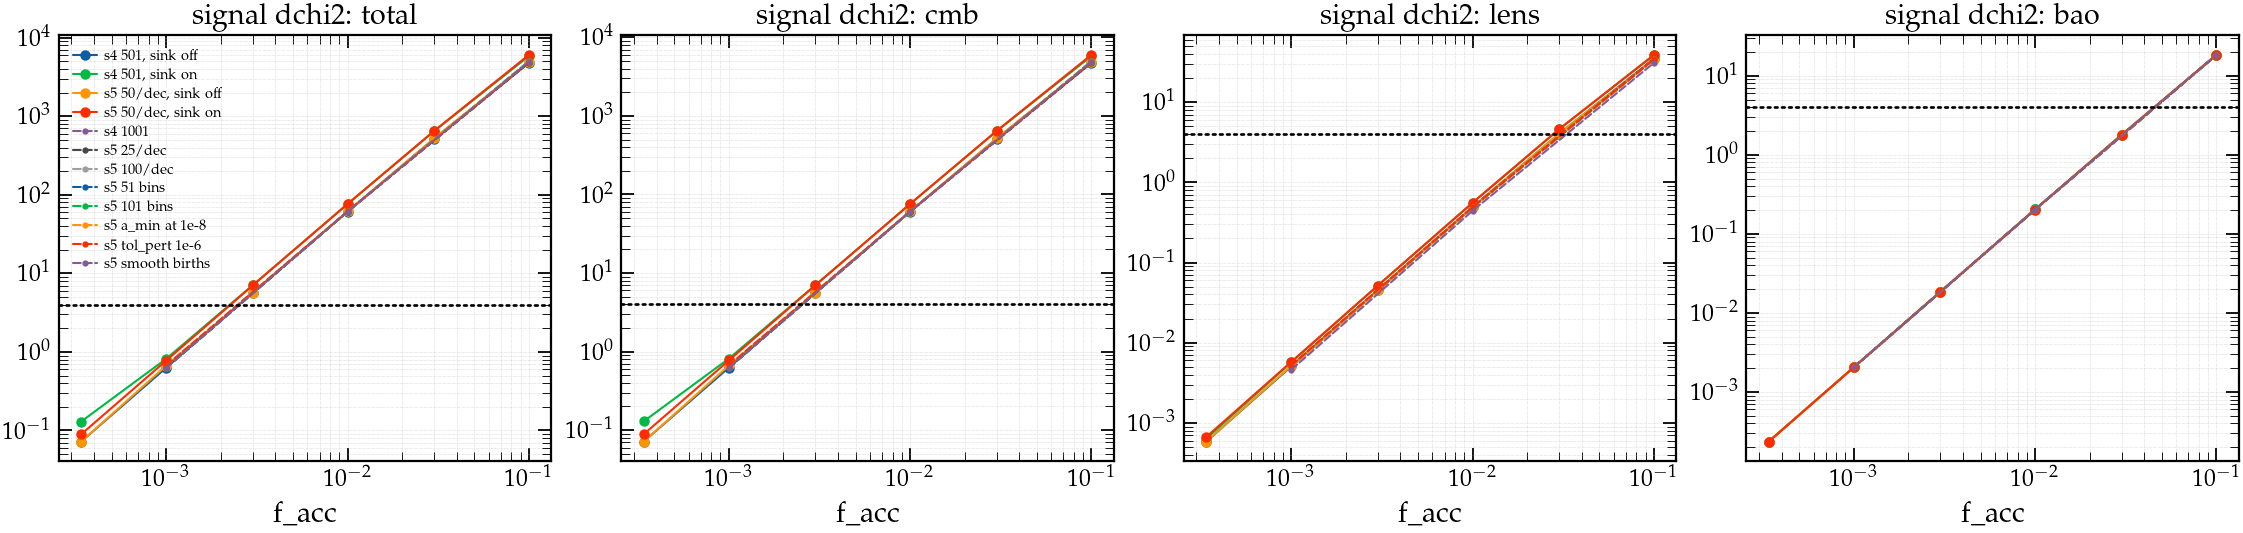

In [7]:
CHI2_LIM = 4.0


def signal(lab, fs):
    return [(f, chi2_parts(res[(lab, f)], res[(lab, F_REF)])) for f in fs
            if f != F_REF and (lab, f) in res and (lab, F_REF) in res]


def f_limit(rows, part='total'):
    """f_acc where the signal chi2 first crosses CHI2_LIM."""
    f = np.array([r[0] for r in rows])
    c = np.array([r[1][part] for r in rows])
    above = np.nonzero(c >= CHI2_LIM)[0]
    if len(above) == 0:
        return np.nan
    i = above[0]
    if i == 0:
        return float(f[0]*np.sqrt(CHI2_LIM/c[0]))
    t = np.log(CHI2_LIM/c[i - 1])/np.log(c[i]/c[i - 1])
    return float(f[i - 1]*(f[i]/f[i - 1])**t)


def limits(lab, fs):
    rows = signal(lab, fs)
    return {part: f_limit(rows, part) for part in PARTS}


lims = {lab: limits(lab, F_CORNER) for lab in CORNERS}
lims.update({lab: limits(lab, F_VARIANT) for lab in VARIANTS})

print('predicted f_lim and ratio to the base setup (same f grid), total and per probe')
print('{:<22s} {:<20s} {:>9} {:>8} {:>8} {:>8} {:>8}'.format('setup', 'base', 'f_lim', 'total', 'CMB', 'lens', 'BAO'))
for lab in SETUPS:
    base = REF if lab in CORNERS else VARIANT_BASE[lab]
    ref = lims[REF] if lab in CORNERS else limits(base, F_VARIANT)
    L = lims[lab]
    print('{:<22s} {:<20s} {:>9.2e} '.format(lab, base, L['total'])
          + ' '.join('{:>8.3f}'.format(L[p]/ref[p]) for p in PARTS))

fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharex=True, constrained_layout=True)
for ax, part in zip(axes, PARTS):
    for lab in SETUPS:
        rows = signal(lab, F_CORNER if lab in CORNERS else F_VARIANT)
        if rows:
            ax.loglog([r[0] for r in rows], [max(r[1][part], 1e-12) for r in rows],
                      'o-' if lab in CORNERS else '.--', lw=1, ms=4, label=lab)
    ax.axhline(CHI2_LIM, color='k', ls=':')
    ax.set_title('signal dchi2: ' + part)
    ax.set_xlabel('f_acc')
    ax.grid(alpha=0.3, which='both')
axes[0].legend(fontsize=7)
plt.show()

## 3. Attribution

Each effect is measured twice in the 2×2 design. Shares split the total log shift (s5+sink vs s4/501/no sink)
into sink (measured with s4), quadrature (measured without sink) and the remaining interaction. Shares are
unstable if the total shift is close to zero.

In [8]:
s4off, s4on, s5off, s5on = (lims[lab]['total'] for lab in CORNERS)
effects = {'sink, with s4 501': s4on/s4off,
           'sink, with s5': s5on/s5off,
           'quadrature, sink off': s5off/s4off,
           'quadrature, sink on': s5on/s4on,
           'both (s5+sink vs s4)': s5on/s4off}
print('predicted f_lim ratios')
for name, r in effects.items():
    print('  {:<24s} x {:.3f}  ({:+.1%})'.format(name, r, r - 1))

tot = np.log(s5on/s4off)
sink_part, quad_part = np.log(s4on/s4off), np.log(s5off/s4off)
print()
print('share of the total log shift: sink {:.0%}, quadrature {:.0%}, interaction {:.0%}'.format(
    sink_part/tot, quad_part/tot, (tot - sink_part - quad_part)/tot))

predicted f_lim ratios
  sink, with s4 501        x 0.889  (-11.1%)
  sink, with s5            x 0.902  (-9.8%)
  quadrature, sink off     x 0.996  (-0.4%)
  quadrature, sink on      x 1.009  (+0.9%)
  both (s5+sink vs s4)     x 0.898  (-10.2%)

share of the total log shift: sink 109%, quadrature 4%, interaction -13%


## 4. Limits from the chains

95% upper limits on f_acc from the local chains (first 30% of each chain file dropped as burn-in).
Comparing chains with the same prior removes the prior effect; the last row shows its size.

In [9]:
def read_chain(folder, burn=0.3):
    """Weights and samples of the longest MontePython run in folder."""
    folder = Path(folder)
    pn = max(folder.glob('*.paramnames'), key=lambda p: int(p.stem.split('_')[1]))
    names = [line.split()[0] for line in pn.read_text().splitlines() if line.strip()]
    chunks = []
    for fn in sorted(folder.glob(pn.stem + '_*.txt')):
        x = np.genfromtxt(fn, invalid_raise=False)
        if x.ndim == 2 and len(x):
            chunks.append(x[int(burn*len(x)):])
    x = np.vstack(chunks)
    return x[:, 0], dict(zip(names, x[:, 2:].T))


def upper_limit(w, f, q=0.95):
    i = np.argsort(f)
    c = np.cumsum(w[i])/np.sum(w)
    return float(f[i][np.searchsorted(c, q)])


CHAIN_RUNS = {'s4 q501 emu, log prior': CHAINS/'connect'/'Lite'/'11',
              's5+sink emu, log prior': CHAINS/'connect'/'new'/'11',
              's4 q501 emu, lin prior': CHAINS/'connect'/'Lite_lin'/'11',
              's5 CLASS no sink, lin prior': CHAINS/'new'/'11'}
chain_lim = {}
for name, folder in CHAIN_RUNS.items():
    w, s = read_chain(folder)
    f = s['f_acc'] if 'f_acc' in s else 10**s['log10f_acc']
    chain_lim[name] = upper_limit(w, f)
    print('{:<28s} 95% f_acc < {:.2e}  ({} points, weight {:.0f})'.format(name, chain_lim[name], len(w), w.sum()))

COMPARE = [('s5+sink vs s4 (log prior)', 's5+sink emu, log prior', 's4 q501 emu, log prior', s5on/s4off),
           ('s5 no sink vs s4 (lin prior)', 's5 CLASS no sink, lin prior', 's4 q501 emu, lin prior', s5off/s4off),
           ('prior only: lin vs log, s4 emu', 's4 q501 emu, lin prior', 's4 q501 emu, log prior', np.nan)]
print()
print('{:<32s} {:>10} {:>10}'.format('limit ratio', 'chains', 'predicted'))
for name, a, b, pred in COMPARE:
    print('{:<32s} {:>10.3f} {:>10.3f}'.format(name, chain_lim[a]/chain_lim[b], pred))

s4 q501 emu, log prior       95% f_acc < 2.85e-03  (1227247 points, weight 4583662)
s5+sink emu, log prior       95% f_acc < 5.19e-03  (59677 points, weight 206872)
s4 q501 emu, lin prior       95% f_acc < 6.05e-03  (1098701 points, weight 4158321)
s5 CLASS no sink, lin prior  95% f_acc < 6.12e-03  (8454 points, weight 45321)

limit ratio                          chains  predicted
s5+sink vs s4 (log prior)             1.823      0.898
s5 no sink vs s4 (lin prior)          1.011      0.996
prior only: lin vs log, s4 emu        2.126        nan


## Reading the result

- Sink share dominant and the chain ratio (log prior) close to the predicted s5+sink ratio → the sink explains it.
- Chain ratio far from the prediction → something outside CLASS: emulator error, parameter degeneracies (the
  prediction keeps ΛCDM fixed) or chain convergence.
- The lin-prior row tests the quadrature alone against a full-CLASS chain, so any mismatch there points at the
  `q501` emulator.